In [3]:
import numpy as np
import math
import matplotlib.pyplot as plt
from matplotlib.patches import Polygon
from matplotlib.collections import PathCollection

In [ ]:
plt.axes()
line = plt.Line2D((2, 20), (1, 10), lw=2)
plt.gca().add_line(line)
plt.axis('scaled')

In [ ]:
pts = np.array([a, a, [3,5]])
p = Polygon(pts, closed=False)
ax = plt.gca()
ax.add_patch(p)
ax.set_xlim(0,7)
ax.set_ylim(0,7)

In [ ]:
class Point:
    def __init__(self, x, y):
        self.x, self.y = x, y
    def __add__(self, point):
        return (self.x + point.x, self.y + point.y)
    def add_x(self, point):
        return (self.x + point.x, self.y)
    def add_y(self, point):
        return (self.x, self.y + point.y)
    def __str__(self):
        return f"{self.x}, {self.y}"

In [ ]:
p1 = Point(2, 5)
p2 = Point(3, 5)
print(f'total_sum = {p1}, just along x = {p1.add_x(p2)}')

In [ ]:
import math

opposite = 5
angle = 90
hypotenuse = 5 / math.sin(math.radians(angle))
adjacent = 5 / math.tan(angle)


In [ ]:
math.sin(angle)

In [ ]:
math.sin(math.radians(angle))

C:\Users\albus\AppData\Local\Temp/ipykernel_15356/3698670051.py:24: UserWarning: Matplotlib is currently using module://matplotlib_inline.backend_inline, which is a non-GUI backend, so cannot show the figure.
  fig.show()


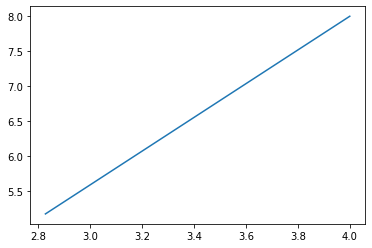

In [13]:
import matplotlib.pyplot as plt
import math

def plot_point(point, angle, length):
     '''
     point - Tuple (x, y)
     angle - Angle you want your end point at in degrees.
     length - Length of the line you want to plot.

     Will plot the line on a 10 x 10 plot.
     '''
     # unpack the first point
     x, y = point

     # find the end point
     endy = y + length * math.sin(math.radians(angle))
     endx = length * math.cos(math.radians(angle))

     # plot the points
     fig = plt.figure()
     ax = plt.subplot(111)
     ax.plot([x, endx], [y, endy])

     fig.show()

plot_point((4,8), -45, 4)

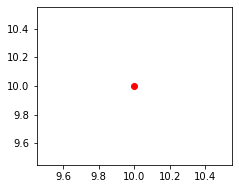

In [8]:
import nanogaps
import matplotlib.pyplot as plt
import math
%matplotlib inline
p = nanogaps.Point(10,10)
nanogaps.plot_point(p)

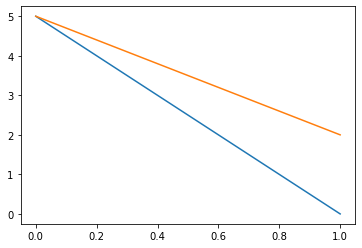

In [29]:
def plot_line_angle(point, angle, length):
    x, y = point
    y_end = y + length * math.sin(math.radians(angle))
    x_end =  length * math.cos(math.radians(angle))
    fig, ax = plt.subplots()
    plt.plot([[x,y], [x_end,y_end]])
plot_line_angle((5,5), 270, 3)

In [24]:
radius = 2
arc_length = lambda r, angle: math.pi * r**2 * angle/360
arc_length(2, 30)

1.0471975511965976

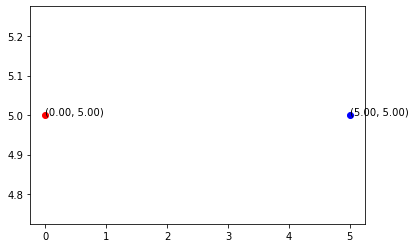

In [73]:
p = nanogaps.Point(5,5)
angle=90
fig, ax = plt.subplots()
ax.plot(p.x, p.y, '-bo', )
x2, y2 = p.x * math.cos(math.radians(angle)), p.y * math.sin(math.radians(angle))
ax.plot(x2, y2, '-ro')
# plt.xlim([-0.5, 10.5])
# plt.ylim([-0.5, 10.5])
for xy in zip((p.x, x2), (p.y, y2)):
    x , y = xy
    ax.annotate('(%.2f, %.2f)'%xy, xy=xy, textcoords='data')

Text(0.5, 1.0, 'Angle Nanogap')

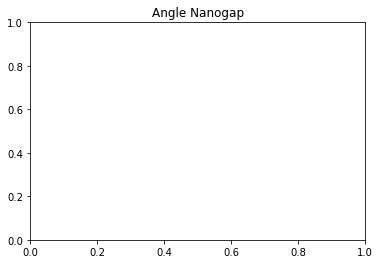

In [1]:
import numpy as np
import matplotlib.pyplot as plt
from matplotlib.patches import Arc
from matplotlib.transforms import IdentityTransform, TransformedBbox, Bbox


class AngleAnnotation(Arc):
    """
    Draws an arc between two vectors which appears circular in display space.
    """
    def __init__(self, xy, p1, p2, size=75, unit="points", ax=None,
                 text="", textposition="inside", text_kw=None, **kwargs):
        """
        Parameters
        ----------
        xy, p1, p2 : tuple or array of two floats
            Center position and two points. Angle annotation is drawn between
            the two vectors connecting *p1* and *p2* with *xy*, respectively.
            Units are data coordinates.

        size : float
            Diameter of the angle annotation in units specified by *unit*.

        unit : str
            One of the following strings to specify the unit of *size*:

            * "pixels": pixels
            * "points": points, use points instead of pixels to not have a
              dependence on the DPI
            * "axes width", "axes height": relative units of Axes width, height
            * "axes min", "axes max": minimum or maximum of relative Axes
              width, height

        ax : `matplotlib.axes.Axes`
            The Axes to add the angle annotation to.

        text : str
            The text to mark the angle with.

        textposition : {"inside", "outside", "edge"}
            Whether to show the text in- or outside the arc. "edge" can be used
            for custom positions anchored at the arc's edge.

        text_kw : dict
            Dictionary of arguments passed to the Annotation.

        **kwargs
            Further parameters are passed to `matplotlib.patches.Arc`. Use this
            to specify, color, linewidth etc. of the arc.

        """
        self.ax = ax or plt.gca()
        self._xydata = xy  # in data coordinates
        self.vec1 = p1
        self.vec2 = p2
        self.size = size
        self.unit = unit
        self.textposition = textposition

        super().__init__(self._xydata, size, size, angle=0.0,
                         theta1=self.theta1, theta2=self.theta2, **kwargs)

        self.set_transform(IdentityTransform())
        self.ax.add_patch(self)

        self.kw = dict(ha="center", va="center",
                       xycoords=IdentityTransform(),
                       xytext=(0, 0), textcoords="offset points",
                       annotation_clip=True)
        self.kw.update(text_kw or {})
        self.text = ax.annotate(text, xy=self._center, **self.kw)

    def get_size(self):
        factor = 1.
        if self.unit == "points":
            factor = self.ax.figure.dpi / 72.
        elif self.unit[:4] == "axes":
            b = TransformedBbox(Bbox.from_bounds(0, 0, 1, 1),
                                self.ax.transAxes)
            dic = {"max": max(b.width, b.height),
                   "min": min(b.width, b.height),
                   "width": b.width, "height": b.height}
            factor = dic[self.unit[5:]]
        return self.size * factor

    def set_size(self, size):
        self.size = size

    def get_center_in_pixels(self):
        """return center in pixels"""
        return self.ax.transData.transform(self._xydata)

    def set_center(self, xy):
        """set center in data coordinates"""
        self._xydata = xy

    def get_theta(self, vec):
        vec_in_pixels = self.ax.transData.transform(vec) - self._center
        return np.rad2deg(np.arctan2(vec_in_pixels[1], vec_in_pixels[0]))

    def get_theta1(self):
        return self.get_theta(self.vec1)

    def get_theta2(self):
        return self.get_theta(self.vec2)

    def set_theta(self, angle):
        pass

    # Redefine attributes of the Arc to always give values in pixel space
    _center = property(get_center_in_pixels, set_center)
    theta1 = property(get_theta1, set_theta)
    theta2 = property(get_theta2, set_theta)
    width = property(get_size, set_size)
    height = property(get_size, set_size)

    # The following two methods are needed to update the text position.
    def draw(self, renderer):
        self.update_text()
        super().draw(renderer)

    def update_text(self):
        c = self._center
        s = self.get_size()
        angle_span = (self.theta2 - self.theta1) % 360
        angle = np.deg2rad(self.theta1 + angle_span / 2)
        r = s / 2
        if self.textposition == "inside":
            r = s / np.interp(angle_span, [60, 90, 135, 180],
                                          [3.3, 3.5, 3.8, 4])
        self.text.xy = c + r * np.array([np.cos(angle), np.sin(angle)])
        if self.textposition == "outside":
            def R90(a, r, w, h):
                if a < np.arctan(h/2/(r+w/2)):
                    return np.sqrt((r+w/2)**2 + (np.tan(a)*(r+w/2))**2)
                else:
                    c = np.sqrt((w/2)**2+(h/2)**2)
                    T = np.arcsin(c * np.cos(np.pi/2 - a + np.arcsin(h/2/c))/r)
                    xy = r * np.array([np.cos(a + T), np.sin(a + T)])
                    xy += np.array([w/2, h/2])
                    return np.sqrt(np.sum(xy**2))

            def R(a, r, w, h):
                aa = (a % (np.pi/4))*((a % (np.pi/2)) <= np.pi/4) + \
                     (np.pi/4 - (a % (np.pi/4)))*((a % (np.pi/2)) >= np.pi/4)
                return R90(aa, r, *[w, h][::int(np.sign(np.cos(2*a)))])

            bbox = self.text.get_window_extent()
            X = R(angle, r, bbox.width, bbox.height)
            trans = self.ax.figure.dpi_scale_trans.inverted()
            offs = trans.transform(((X-s/2), 0))[0] * 72
            self.text.set_position([offs*np.cos(angle), offs*np.sin(angle)])

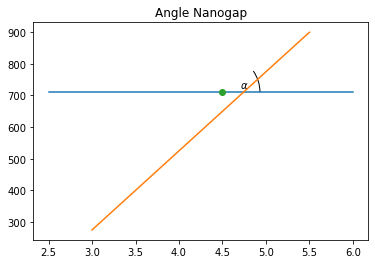

In [91]:
fig, ax = plt.subplots()
fig.canvas.draw()
ax.set_title('Angle Nanogap')
center = (4.5, 710)
p1 = [(2.5, 710), (6.0, 710)]
p2 = [(3.0, 275), (5.5, 900)]
line1, = ax.plot(*zip(*p1))
line2, = ax.plot(*zip(*p2))
point, = ax.plot(*center, marker="o")
am1 = AngleAnnotation(center, p1[1], p2[1], ax=ax, size=75, text=r"$\alpha$")

In [92]:
am1.get_theta2()

34.64555719910562

In [93]:
p1_np = np.array(p1)

In [94]:
p1_np

array([[  2.5, 710. ],
       [  6. , 710. ]])

## Flexural Phonon Scaling to Graphne Resistivity

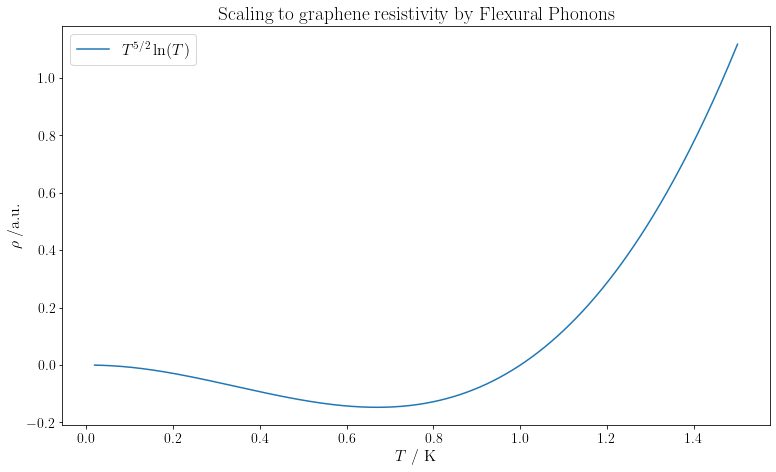

In [4]:
from matplotlib import rc
import numpy as np
golden_mean = (np.sqrt(5) - 1) / 2  # Aesthetic ratio
fig_width_pt = 800.0  # Columnwidth
inches_per_pt = 1 / 72.27  # Convert pt to inches
fig_width = fig_width_pt * inches_per_pt
fig_height = fig_width * golden_mean  # height in inches
fig_size = [fig_width, fig_height]

params = {
    "backend": "ps",
    "axes.labelsize": 16,
    "font.size": 16,
    "legend.fontsize": 16,
    "xtick.labelsize": 14,
    "ytick.labelsize": 14,
    "text.usetex": True,
    "figure.figsize": fig_size,
    "font.family": "serif",
    "font.serif": "Computer Modern Roman",
    "legend.frameon": True,
    "savefig.dpi": 300,
}
plt.rcParams.update(params)

fig, ax = plt.subplots(figsize=fig_size)

flexural_phonon = lambda T: T**(5/2) * np.log(T)
temp_array = np.linspace(0.02, 1.5, num=500)
ax.set_xlabel('$T$ / K')
ax.set_ylabel('$\\rho\; /\mathrm{a.u.}$')
ax.plot(temp_array, flexural_phonon(temp_array), label='$T^{5/2}\ln(T)$')
ax.legend()
plt.title('Scaling to graphene resistivity by Flexural Phonons')
fig.tight_layout()
plt.savefig('scaling_flexural_phonon.pdf')

## Graphene Dispersion

C:\Users\albus\AppData\Local\Temp/ipykernel_18600/133736950.py:19: MatplotlibDeprecationWarning: Calling gca() with keyword arguments was deprecated in Matplotlib 3.4. Starting two minor releases later, gca() will take no keyword arguments. The gca() function should only be used to get the current axes, or if no axes exist, create new axes with default keyword arguments. To create a new axes with non-default arguments, use plt.axes() or plt.subplot().
  ax = fig.gca(projection='3d')


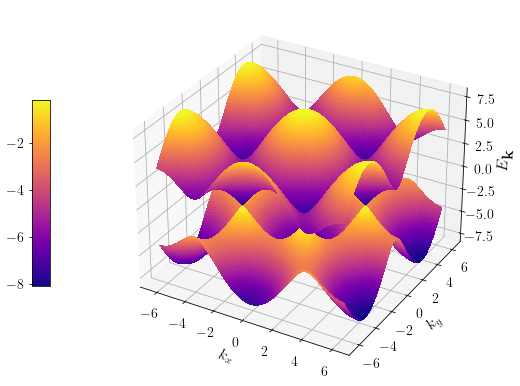

In [22]:
# 3D Plot of graphene dispersion

from matplotlib import pyplot as plt
from mpl_toolkits.mplot3d import Axes3D
from matplotlib import cm
from matplotlib.ticker import LinearLocator, FormatStrFormatter
import numpy as np

sqrt = np.sqrt
cos = np.cos

# Constants
a = 1.0
d = a*np.sqrt(3)
t = 2.7
t2 = 0.5

fig = plt.figure()
ax = fig.gca(projection='3d')
x = np.arange(-2.0*np.pi, 2.0*np.pi, 0.1)
y = np.arange(-2.0*np.pi, 2.0*np.pi, 0.1)
x, y = np.meshgrid(x, y)

f=t*sqrt(3.0+2.0*cos(a*x)+4.0*cos(a/2.0*x)*cos(d/2.0*y))

surf = ax.plot_surface(x, y, f, rstride=1, cstride=1, cmap=plt.get_cmap('plasma'),
                       linewidth=0, antialiased=False)


f=-f
surf = ax.plot_surface(x, y, f, rstride=1, cstride=1, cmap=plt.get_cmap('plasma'),
                       linewidth=1, antialiased=False)
fig.colorbar(surf, shrink=.5, aspect=10, location='left')
ax.set_xlabel('$k_x$')
ax.set_ylabel('$k_y$')
ax.set_zlabel(r"$E_\textbf{k}$")
plt.show()

In [3]:
conversion = lambda dollar: dollar*2.54/1
conversion(6), conversion(28), conversion(32), conversion(44), conversion(77)

(15.24, 71.12, 81.28, 111.76, 195.58)

<ipython-input-4-9a4a90c19f9f>:3: RuntimeWarning: divide by zero encountered in power
  y = lambda x: x ** -.5


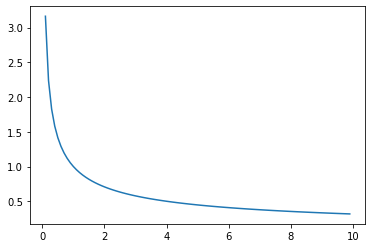

In [4]:
fig = plt.figure()
x = np.arange(0, 10, 0.1)
y = lambda x: x ** -.5
plt.plot(x, y(x))

In [5]:
math.factorial(5)

120

In [26]:
P_poisson = lambda event, mean_number_of_event: \
            math.exp(-mean_number_of_event)*mean_number_of_event**event/math.factorial(event)

n_peaks = 5
n_peak_catched = 3
n_cases = P_poisson(1, n_peak_catched/n_peaks) * 25
n_cases

8.232174541410398

In [17]:
n_peaks = 60
n_peak_catched = 100
n_cases = P_poisson(2, n_peak_catched/n_peaks)
n_cases

0.26232722616328036

In [24]:
P_poisson(0, 0.61) * 200

108.67017381489997

In [25]:
P_poisson(1, 1/500) * 500

0.9980019986673332

In [27]:
P_poisson(3, 0.95)

0.055263680830717164

In [28]:
3/5

0.6

# Simulate a Gate-Controlled Feedback Electroburning Traces

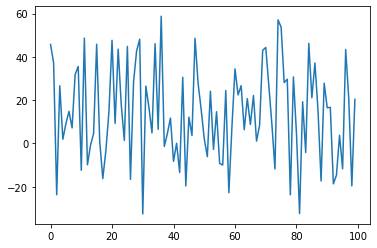

In [6]:
import numpy as np                    
import matplotlib.pyplot as plt 

random_number1 =np.random.randint(0,200,1)
random_number2=np.random.normal(10,20,100)
random_number=np.concatenate((random_number1,random_number2))
np.random.shuffle(random_number2)
plt.plot(random_number2)
plt.savefig('C:/Users/albus/Desktop/projects/thesis/Latex templates/OxThesis-master/chapter_fabrication/figures/purely_random.svg')

## Calculate the Luttinger Parameter based on the relation $g = [1 + \frac{2U}{\Delta\epsilon}]^{-1/2}$

In [36]:
g = lambda U,D: (1+2*U/D) ** (-1/2)
g(0.150, 0.001), g(0.156, 0.002), g(0.100, 0.002), g(0.100, 0.005), g(0.100, 0.010)

(0.0576390417704235,
 0.07980868844676221,
 0.09950371902099892,
 0.15617376188860607,
 0.2182178902359924)

## From article $\textit{Single Electron Transport in Ropes of Carbon Nanotubes}$

In [1]:
import math

# Define Constants
l_tube = 200 # nm
l_gnr  = 30 # nm
h = 4.1357e-15 # eV/s
vf_tube = 8.1e5 # m/s
c_star = 1e6 # m/s
kb = 8.62e-5
hbar = h/(2*math.pi)

# Define Lambda Functions
avg_level_spacing = lambda L: 500 /L # meV
level_spacing_tube = lambda L: h*vf_tube/(2*L)
energy_spectrum_gnr = lambda n,m,W,L: hbar * c_star * math.sqrt((n*math.pi/W)**2+(m*math.pi/L)**2)
charging_energy   = lambda L: 1400 /L # meV

# A bit of Testing with the numbers reported on the paper
charging_energy(l_tube), avg_level_spacing(l_tube)
charging_energy(l_gnr), avg_level_spacing(l_gnr)
level_spacing_tube(3e-6)*1e3


0.5583195

## From article $\textit{Exceptional ballistic transport in epitaxial graphene nanoribbons}$

In [74]:
def print_energy_K_meV(energy):
    print(energy/kb, energy*1e3)

# Define GNR size
w_gnr = 40e-9
l_gnr = 1e-6

# Calculate the energy of the first two bands. The bands with n=0 are special as they are associated to edges.
E_1_0 = energy_spectrum_gnr(1,0,w_gnr,l_gnr)
E_0_1 = energy_spectrum_gnr(0,1,w_gnr,l_gnr)


print_energy_K_meV(E_1_0), print_energy_K_meV(E_0_1)

599.7244779582367 51.69624999999999
23.988979118329468 2.06785


(None, None)

In [2]:
# An Estimation for the first two states of a GNR with similar characteristics to mine

# Define GNR size
w_gnr = 1.12e-9
l_gnr = 30e-9 

# Calculate the energy of the first two bands. Bear in mind this is a COVE GNR so the energy spectrum might be different
E_1_0 = energy_spectrum_gnr(1,0,w_gnr,l_gnr)
E_0_1 = energy_spectrum_gnr(0,1,w_gnr,l_gnr)
E_0_0 = energy_spectrum_gnr(0,0,w_gnr,l_gnr)

print_energy_K_meV(E_1_0), print_energy_K_meV(E_0_1), print_energy_K_meV(E_0_0)

NameError: name 'print_energy_K_meV' is not defined

In [29]:
import numpy as np


class Sequence:

    def __init__(self, start, stop, step):
        self.start = start
        self.stop = stop
        self.step = step

    def sweep(self, start, stop, step):
        self.arr = np.linspace(start, stop, step)
        return self

    def reverse(self):        
        self.arr = self.arr[::-1]
        return self




s = Sequence(1, 10, 1)
s.sweep(10, 1, 10)
s.reverse()
s.sweep(10, 1, 10).reverse().reverse()
        
        

array([10.,  9.,  8.,  7.,  6.,  5.,  4.,  3.,  2.,  1.])

In [6]:
to_cm_1 = lambda x: x*8.066
to_cm_1(100)

806.6

In [7]:
5/16

0.3125

In [8]:
20*2/2**7

0.3125